In [3]:
!pip install huggingface_hub

Login process


In [4]:
from huggingface_hub import notebook_login

In [5]:
notebook_login()

access the api keys

In [ ]:
from google.colab import userdata
userdata.get('HF_TOKEN_READ')

In [ ]:
from google.colab import userdata
userdata.get('HF_TOKEN')

In [8]:
import os
from huggingface_hub import HfApi
from google.colab import userdata

Installing dataset library

In [9]:
!pip install datasets

In [10]:
from datasets import load_dataset

Loading imdb dataset

In [11]:
dataset=load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [12]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [13]:
dataset["train"][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [14]:
dataset["train"][:10]

{'text': ['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far b

Convert the data into pandas dataframe

In [15]:
import pandas as pd
df=pd.DataFrame(dataset["train"][:10])
print(df)

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
5  I would put this at the top of my list of film...      0
6  Whoever wrote the screenplay for this movie ob...      0
7  When I first saw a glimpse of this movie, I qu...      0
8  Who are these "They"- the actors? the filmmake...      0
9  This is said to be a personal film for Peter B...      0


Check Dataset Features

In [16]:
dataset["train"].features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Load Specific Dataset Split

In [17]:
dataset2=load_dataset("imdb",split="train")

In [18]:
print(dataset2)

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


Dataset Information

In [19]:
print(dataset['train'].features)
print(dataset['train'].column_names)
print(dataset['train'].num_rows)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
['text', 'label']
25000


Shuffle Dataset

In [20]:
shuffled_dataset = dataset['train'].shuffle(seed=42)

In [21]:
print(shuffled_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


Selecting Subset of Dataset

In [22]:
small_dataset = shuffled_dataset.select(range(100))

In [23]:
print(small_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 100
})


Filtering Dataset

In [24]:
filtered_data = dataset['train'].filter(
    lambda x: len(x['text']) < 100
)

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [25]:
print(filtered_data)

Dataset({
    features: ['text', 'label'],
    num_rows: 9
})


Adding Word Count Column

In [26]:

def add_word_count(example):
    example['word_count'] = len(example['text'].split())
    return example
dataset = dataset['train'].map(add_word_count)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

 Access Word Count

In [27]:
print(dataset[0]['word_count'])

288


 Streaming Large Dataset

In [28]:
stream_dataset = load_dataset(
    "openwebtext",
    split="train",
    streaming=True
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Reading Streaming Dataset

In [29]:
for i, sample in enumerate(stream_dataset):

    print(sample)

    if i > 5:
        break

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t

Tweet Sentiment Dataset

In [30]:
sentiment_dataset = load_dataset(
    "tweet_eval",
    "sentiment"
)

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Visualizing Dataset

In [31]:
!pip install matplotlib

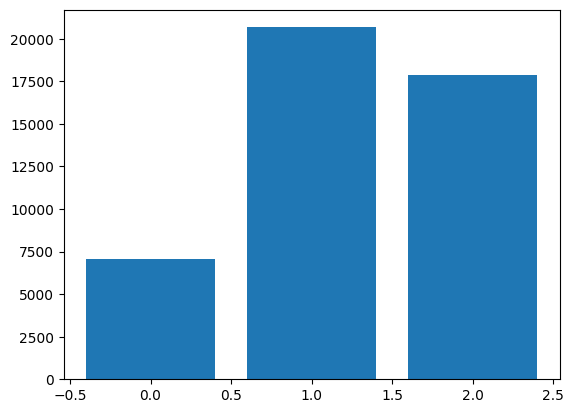

In [32]:
import matplotlib.pyplot as plt
from collections import Counter

labels = [x['label'] for x in sentiment_dataset['train']]

counter = Counter(labels)

plt.bar(counter.keys(), counter.values())

plt.show()

Most Common Words

In [33]:
from collections import Counter

words = []

for sample in sentiment_dataset['train']:

    words.extend(sample['text'].split())

counter = Counter(words)

print(counter.most_common(20))

[('the', 34587), ('to', 20490), ('@user', 16830), ('in', 12896), ('on', 12311), ('a', 12011), ('and', 11797), ('of', 10581), ('I', 10555), ('for', 9543), ('is', 9069), ('with', 7271), ('be', 6967), ('at', 6820), ('you', 6707), ('may', 5518), ('it', 5006), ('have', 4128), ('that', 4055), ('tomorrow', 4039)]


Word Cloud Visualization

In [34]:
!pip install wordcloud

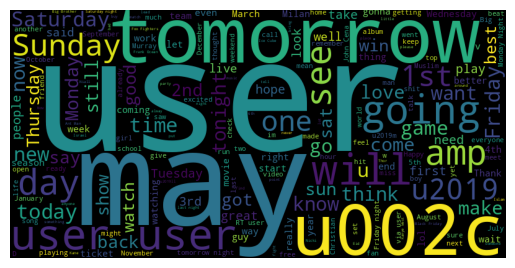

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(words)

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()